In [147]:
import json
import pandas as pd

### JSON vs JSONL

- **JSON** stores one complete object or array in a single file.
- **JSONL** stores one JSON object per line, which is easier for streaming and large datasets.


In [148]:
import random
from datetime import datetime, timedelta
from uuid import uuid4

random.seed(42)

products = [
    ("B001", "Wireless Earbuds"),
    ("B002", "Stainless Steel Water Bottle"),
    ("B003", "Laptop Stand"),
    ("B004", "Coffee Maker"),
    ("B005", "Bluetooth Speaker"),
    ("B006", "Yoga Mat"),
    ("B007", "Desk Lamp"),
    ("B008", "Phone Case"),
    ("B009", "Backpack"),
    ("B010", "Mechanical Keyboard"),
]

review_phrases = [
    "excellent build quality",
    "works as expected",
    "good value for money",
    "easy to use",
    "highly recommended",
    "battery life could be better",
    "packaging was neat",
    "feels premium",
    "arrived on time",
    "customer support was helpful",
]

review_titles = [
    "Great product",
    "Worth buying",
    "Satisfied with purchase",
    "Could be better",
    "Amazing quality",
    "Solid choice",
    "Pretty decent",
    "Not bad at all",
]

start_date = datetime(2024, 1, 1)
reviews = []

for _ in range(2000):
    product_id, product_name = random.choice(products)
    rating = random.randint(1, 5)
    phrase = random.choice(review_phrases)
    title = random.choice(review_titles)
    review_date = start_date + timedelta(days=random.randint(0, 365))

    # Occasionally omit details (set to None) to simulate missing data
    if random.random() < 0.8:  # 80% records have details
        details = {
            "Date First Available": review_date.strftime("%B %d, %Y"),
            "Manufacturer": f"Brand {random.choice(['A', 'B', 'C', 'D'])}",
            "ASIN": f"ASIN{random.randint(1000000, 9999999)}",
        }
    else:
        details = None

    reviews.append(
        {
            "review_id": str(uuid4()),
            "product_id": product_id,
            "product_name": product_name,
            "reviewer_id": f"R{random.randint(100000, 999999)}",
            "rating": rating,
            "review_title": title,
            "review_text": f"This product has {phrase}. {title.lower()}.",
            "verified_purchase": random.choice([True, False]),
            "helpful_votes": random.randint(0, 50),
            "review_date": review_date.strftime("%Y-%m-%d"),
            "date": review_date.strftime("%Y-%m-%d"),
            "details": details,
        }
    )

reviews_df = pd.DataFrame(reviews)
reviews_df.head()


,review_id,product_id,product_name,reviewer_id,rating,review_title,review_text,verified_purchase,helpful_votes,review_date,date,details
0,49625377-e444-4d3e-8e33-780aaa3ee59b,B002,Stainless Steel Water Bottle,R719176,1,Could be better,This product has highly recommended. could be ...,False,2,2024-04-24,2024-04-24,"{'Date First Available': 'April 24, 2024', 'Ma..."
1,583c2647-a5cb-4d56-a259-8f6a88a836f8,B001,Wireless Earbuds,R331148,1,Could be better,This product has easy to use. could be better.,False,37,2024-09-15,2024-09-15,"{'Date First Available': 'September 15, 2024',..."
2,beb8027a-f4a7-45d7-b942-82fe92875307,B005,Bluetooth Speaker,R207175,1,Pretty decent,This product has good value for money. pretty ...,True,24,2024-06-23,2024-06-23,"{'Date First Available': 'June 23, 2024', 'Man..."
3,e9218ec2-a71e-4730-829b-a845d98002dc,B002,Stainless Steel Water Bottle,R182627,3,Amazing quality,This product has battery life could be better....,False,40,2024-01-23,2024-01-23,"{'Date First Available': 'January 23, 2024', '..."
4,e286680f-5b2a-4c61-8d43-610405182a29,B010,Mechanical Keyboard,R183667,3,Could be better,This product has customer support was helpful....,True,6,2024-12-26,2024-12-26,"{'Date First Available': 'December 26, 2024', ..."


In [149]:
from pathlib import Path

output_path = Path('/Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/20_RAG_Pipeline/data/data.jsonl')

with output_path.open('w', encoding='utf-8') as file_handle:
    for record in reviews:
        file_handle.write(json.dumps(record) + '\n')

print(f'Wrote {len(reviews)} reviews to {output_path}')


Wrote 2000 reviews to /Users/kishorkumarparoi/Desktop/Maven - The AI Engineering Bootcamp /Resources/AIE5-main/20_RAG_Pipeline/data/data.jsonl


In [150]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as file_handle:
    for _ in range(5):
        line = file_handle.readline()
        review_record = json.loads(line)
        print(review_record)

{'review_id': '49625377-e444-4d3e-8e33-780aaa3ee59b', 'product_id': 'B002', 'product_name': 'Stainless Steel Water Bottle', 'reviewer_id': 'R719176', 'rating': 1, 'review_title': 'Could be better', 'review_text': 'This product has highly recommended. could be better.', 'verified_purchase': False, 'helpful_votes': 2, 'review_date': '2024-04-24', 'date': '2024-04-24', 'details': {'Date First Available': 'April 24, 2024', 'Manufacturer': 'Brand A', 'ASIN': 'ASIN2458591'}}
{'review_id': '583c2647-a5cb-4d56-a259-8f6a88a836f8', 'product_id': 'B001', 'product_name': 'Wireless Earbuds', 'reviewer_id': 'R331148', 'rating': 1, 'review_title': 'Could be better', 'review_text': 'This product has easy to use. could be better.', 'verified_purchase': False, 'helpful_votes': 37, 'review_date': '2024-09-15', 'date': '2024-09-15', 'details': {'Date First Available': 'September 15, 2024', 'Manufacturer': 'Brand B', 'ASIN': 'ASIN8038374'}}
{'review_id': 'beb8027a-f4a7-45d7-b942-82fe92875307', 'product_id'

In [151]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as file_handle:
   first_line = json.loads(file_handle.readline())

In [152]:
first_line

{'review_id': '49625377-e444-4d3e-8e33-780aaa3ee59b',
 'product_id': 'B002',
 'product_name': 'Stainless Steel Water Bottle',
 'reviewer_id': 'R719176',
 'rating': 1,
 'review_title': 'Could be better',
 'review_text': 'This product has highly recommended. could be better.',
 'verified_purchase': False,
 'helpful_votes': 2,
 'review_date': '2024-04-24',
 'date': '2024-04-24',
 'details': {'Date First Available': 'April 24, 2024',
  'Manufacturer': 'Brand A',
  'ASIN': 'ASIN2458591'}}

Filter Items that has been observed first item after 2022

In [153]:
def filter_data(data: dict) -> bool:
    try:
        date_str = data.get("details", {}).get("Date First Available", "")
        if date_str:
            datetime.strptime(date_str, "%B %d, %Y")
            return True
        else:
            return False
    except ValueError:
        pass
    return False

In [154]:
with open('../data/data.jsonl', 'r', encoding='utf-8') as fp, \
     open('../data/Data_With_Details.jsonl', 'w', encoding='utf-8') as fp_out, \
     open('../data/Data_No_details.jsonl', 'w', encoding='utf-8') as fp_no_date, \
     open('../data/Data_With_Details_After_2025.jsonl', 'w', encoding='utf-8') as fp_after_2025:
    i = 0
    for line in fp:
        data = json.loads(line.strip())
        i += 1
        details = data.get("details")
        # Records without details -> separate file
        if not details:
            json.dump(data, fp_no_date)
            fp_no_date.write('\n')
            fp_no_date.flush()
            continue
        # Write all records that have details
        json.dump(data, fp_out)
        fp_out.write('\n')
        fp_out.flush()
        # Optional: also write records observed after 2022 to a separate file
        date_str = details.get('Date First Available', '')
        try:
            year = int(date_str.strip()[-4:]) if len(date_str) >= 4 else None
        except Exception:
            year = None
        if year and year > 2022:
            json.dump(data, fp_after_2025)
            fp_after_2025.write('\n')
            fp_after_2025.flush()
        if i % 1000 == 0:
            print(f"Processed {i} lines")

Processed 1000 lines
Processed 2000 lines


In [155]:
df = pd.read_json('../data/Data_With_Details.jsonl', lines=True)
print(df.head())

                              review_id product_id  \
0  49625377-e444-4d3e-8e33-780aaa3ee59b       B002   
1  583c2647-a5cb-4d56-a259-8f6a88a836f8       B001   
2  beb8027a-f4a7-45d7-b942-82fe92875307       B005   
3  e9218ec2-a71e-4730-829b-a845d98002dc       B002   
4  e286680f-5b2a-4c61-8d43-610405182a29       B010   

                   product_name reviewer_id  rating     review_title  \
0  Stainless Steel Water Bottle     R719176       1  Could be better   
1              Wireless Earbuds     R331148       1  Could be better   
2             Bluetooth Speaker     R207175       1    Pretty decent   
3  Stainless Steel Water Bottle     R182627       3  Amazing quality   
4           Mechanical Keyboard     R183667       3  Could be better   

                                         review_text  verified_purchase  \
0  This product has highly recommended. could be ...              False   
1     This product has easy to use. could be better.              False   
2  This product h

<Axes: xlabel='helpful_votes'>

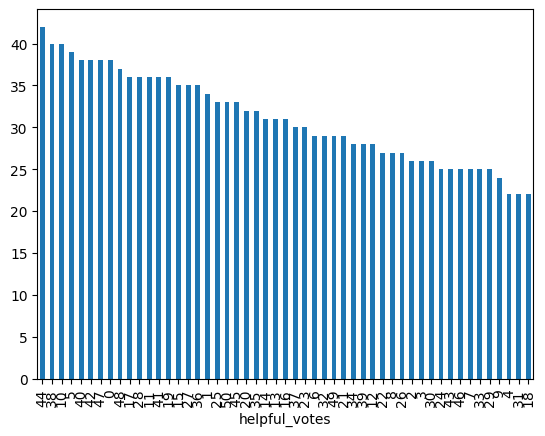

In [156]:
df['helpful_votes'].value_counts().plot(kind='bar')

In [157]:
df.head()

,review_id,product_id,product_name,reviewer_id,rating,review_title,review_text,verified_purchase,helpful_votes,review_date,date,details
0,49625377-e444-4d3e-8e33-780aaa3ee59b,B002,Stainless Steel Water Bottle,R719176,1,Could be better,This product has highly recommended. could be ...,False,2,2024-04-24,2024-04-24,"{'Date First Available': 'April 24, 2024', 'Ma..."
1,583c2647-a5cb-4d56-a259-8f6a88a836f8,B001,Wireless Earbuds,R331148,1,Could be better,This product has easy to use. could be better.,False,37,2024-09-15,2024-09-15,"{'Date First Available': 'September 15, 2024',..."
2,beb8027a-f4a7-45d7-b942-82fe92875307,B005,Bluetooth Speaker,R207175,1,Pretty decent,This product has good value for money. pretty ...,True,24,2024-06-23,2024-06-23,"{'Date First Available': 'June 23, 2024', 'Man..."
3,e9218ec2-a71e-4730-829b-a845d98002dc,B002,Stainless Steel Water Bottle,R182627,3,Amazing quality,This product has battery life could be better....,False,40,2024-01-23,2024-01-23,"{'Date First Available': 'January 23, 2024', '..."
4,e286680f-5b2a-4c61-8d43-610405182a29,B010,Mechanical Keyboard,R183667,3,Could be better,This product has customer support was helpful....,True,6,2024-12-26,2024-12-26,"{'Date First Available': 'December 26, 2024', ..."


<Axes: xlabel='rating'>

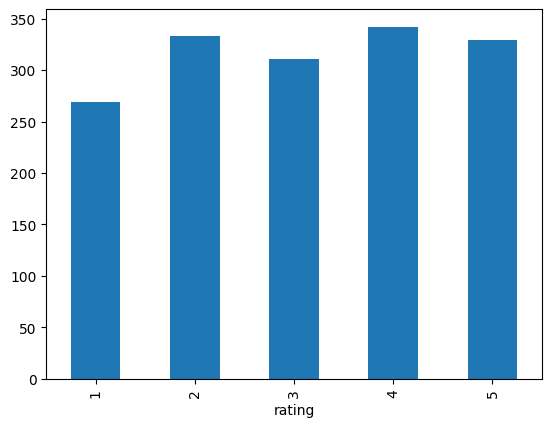

In [158]:
df_ratings = df['rating'].value_counts().sort_index()
df_ratings.plot(kind='bar')

In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          1584 non-null   str           
 1   product_id         1584 non-null   str           
 2   product_name       1584 non-null   str           
 3   reviewer_id        1584 non-null   str           
 4   rating             1584 non-null   int64         
 5   review_title       1584 non-null   str           
 6   review_text        1584 non-null   str           
 7   verified_purchase  1584 non-null   bool          
 8   helpful_votes      1584 non-null   int64         
 9   review_date        1584 non-null   str           
 10  date               1584 non-null   datetime64[us]
 11  details            1584 non-null   object        
dtypes: bool(1), datetime64[us](1), int64(2), object(1), str(7)
memory usage: 137.8+ KB
